### 1-D Inversion — gradiometry dispersion -> Vs(z)

Invert the **section-median** Rayleigh phase-velocity dispersion produced in
`sloth.ipynb` for a single, robust 1-D shear-velocity profile, using `evodcinv`
(CPSO global search) with the `disba` forward solver. Because the lateral
coherence of the gradiometry section is modest (~+0.16), the section-median
curve is the right product: the dispersion is well constrained even though
fine lateral Vs variation is not.

Band 3-8 Hz at c ~ 340 m/s gives wavelengths ~42-113 m, so Rayleigh depth
sensitivity is roughly **15-55 m** -- the layer bounds below are set for that
zone, with a half-space beneath.

In [1]:
import os, sys, pickle, warnings
import numpy as np
np.Inf = np.inf  # shim for evodcinv on newer NumPy (matches das_ani)
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from evodcinv import EarthModel, Layer, Curve
from disba import PhaseDispersion

sys.path.append('..')

#### 1. Load the gradiometry dispersion + take the section median

In [2]:
prod = np.load("../results/gradiometry_dispersion.npz", allow_pickle=True)
freqs     = prod["freqs"]          # (nf,) Hz
positions = prod["positions"]      # (nx,) m
vel       = prod["vel"]            # (nx, nf) phase velocity m/s, NaN where invalid
print("loaded:", dict(zip(["nx", "nf"], vel.shape)), "| meta:", str(prod["meta_json"]))

# Section-median dispersion + robust spread across positions.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    c_med = np.nanmedian(vel, axis=0)
    c_lo, c_hi = np.nanpercentile(vel, [25, 75], axis=0)

ok = np.isfinite(c_med)
f_obs, c_obs = freqs[ok], c_med[ok]
clo, chi = c_lo[ok], c_hi[ok]
print(f"\n{len(f_obs)} usable dispersion points:")
for f, c, lo, hi in zip(f_obs, c_obs, clo, chi):
    print(f"  {f:4.1f} Hz : {c:4.0f} m/s   (IQR {lo:.0f}-{hi:.0f})")

loaded: {'nx': 152, 'nf': 9} | meta: {"date": "20211012", "band": "235_487", "sources": "s1+s2", "aperture_m": 350, "vs_range": "20-120", "stack": "median", "quality_max": 1.0}

9 usable dispersion points:
   3.3 Hz :  367 m/s   (IQR 351-384)
   3.9 Hz :  358 m/s   (IQR 340-374)
   4.4 Hz :  335 m/s   (IQR 320-355)
   5.0 Hz :  338 m/s   (IQR 326-358)
   5.6 Hz :  336 m/s   (IQR 313-357)
   6.1 Hz :  329 m/s   (IQR 312-354)
   6.7 Hz :  331 m/s   (IQR 314-351)
   7.2 Hz :  335 m/s   (IQR 311-350)
   7.8 Hz :  338 m/s   (IQR 315-367)


#### 2. QC the dispersion curve

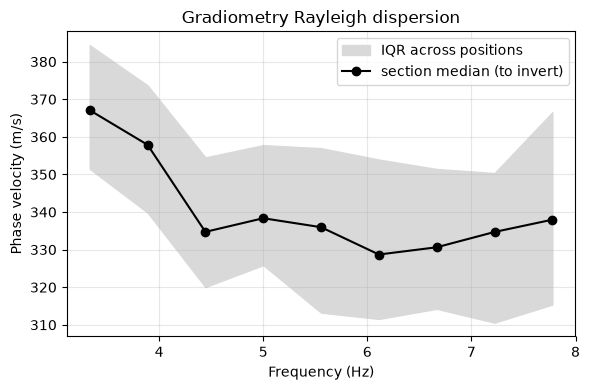

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(f_obs, clo, chi, color="0.85", label="IQR across positions")
ax.plot(f_obs, c_obs, "ko-", label="section median (to invert)")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Phase velocity (m/s)")
ax.set_title("Gradiometry Rayleigh dispersion"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

#### 3. Build the dispersion curve + layered search space

`evodcinv` wants **period ascending** and **velocity in km/s**. Layers are
shallow (resolved zone ~15-55 m) with a half-space below; `increasing_velocity`
forbids low-velocity zones, and density is fixed (it barely affects Rayleigh
phase velocity).

In [4]:
order   = np.argsort(1.0 / f_obs)
period  = (1.0 / f_obs)[order]
vel_km  = (c_obs / 1000.0)[order]
curves  = [Curve(period, vel_km, 0, "rayleigh")]   # mode 0, Rayleigh, phase

model = EarthModel()
# [thickness bounds km], [Vs bounds km/s], [Poisson bounds]   cumulative max depth
model.add(Layer([0.003, 0.012], [0.10, 0.45], [0.32, 0.34]))   # 3-12 m   (<=12 m)
model.add(Layer([0.008, 0.020], [0.20, 0.55], [0.32, 0.34]))   # 8-20 m   (<=32 m)
model.add(Layer([0.012, 0.030], [0.30, 0.70], [0.32, 0.34]))   # 12-30 m  (<=62 m)
model.add(Layer([0.020, 0.050], [0.40, 0.90], [0.32, 0.34]))   # half-space region

model.configure(
    optimizer="cpso",                 # particle-swarm global search
    misfit="rmse",
    density=lambda x: 1.0 + 0.0 * x,  # fixed 1.0 g/cm^3
    increasing_velocity=True,         # no low-velocity zones
    optimizer_args={"popsize": 20, "maxiter": 1500, "workers": -1, "seed": 42},
)
print("EarthModel + optimizer configured (4 layers, CPSO).")

EarthModel + optimizer configured (4 layers, CPSO).


#### 4. Run the inversion

Run 1   |                    |   0% [0:00:00 / 0:00:00] - Misfit: inf

Inverting (CPSO, 5 runs)... this can take a minute.


Run 1   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0045
Run 2   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0045
Run 3   |████████████████████| 100% [0:00:20 / 0:00:00] - Misfit: 0.0045
Run 4   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0045
Run 5   |████████████████████| 100% [0:00:19 / 0:00:00] - Misfit: 0.0045


--------------------------------------------------------------------------------
Best model out of 150000 models (5 runs)

Velocity model                                    Model parameters
----------------------------------------          ------------------------------
         d        vp        vs       rho                   d        vs        nu
      [km]    [km/s]    [km/s]   [g/cm3]                [km]    [km/s]       [-]
----------------------------------------          ------------------------------
    0.0073    0.7211    0.3552    1.0000              0.0073    0.3552    0.3398
    0.0200    0.6912    0.3552    1.0000              0.0200    0.3552    0.3206
    0.0300    0.7215    0.3552    1.0000              0.0300    0.3552    0.3400
    1.0000    1.2607    0.6319    1.0000                   -    0.6319    0.3322
----------------------------------------          ------------------------------

Number of layers: 4
Number of parameters: 11
Best model misfit: 0.0045
---------

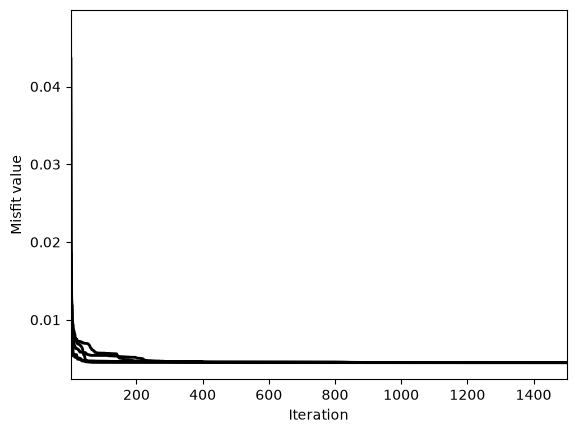

In [5]:
print("Inverting (CPSO, 5 runs)... this can take a minute.")
res = model.invert(curves, maxrun=5)
print(res)
res.plot_misfit(); plt.show()

#### 5. Vs(z) profile + dispersion fit

mean of top 45001 models | misfit 0.0045-0.0045


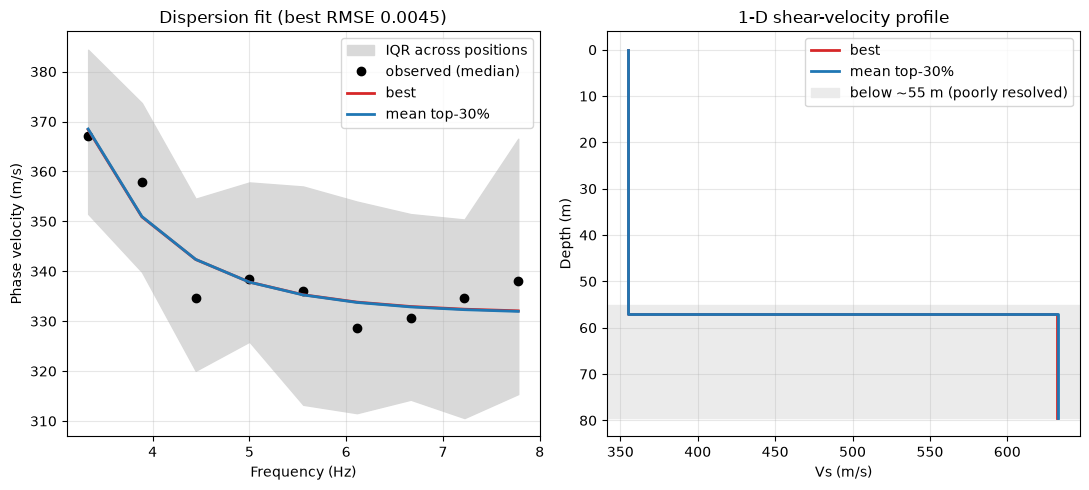

In [6]:
def get_mean_model(res, percent=30):
    """Average the best `percent` of sampled models (matches das_ani.src.inv)."""
    idx = np.argsort(res.misfits)
    n = int(np.floor((percent / 100.0) * len(idx)))
    sel = res.models[idx][:n + 1]
    print(f"mean of top {len(sel)} models | misfit "
          f"{res.misfits[idx][0]:.4f}-{res.misfits[idx][n]:.4f}")
    return np.squeeze(np.mean(sel, axis=0))

def vs_profile(m, zmax=80.0, dz=0.5):
    """Step Vs(z) from an evodcinv model array (cols: thick,Vp,Vs,rho in km/km/s)."""
    th = m[:, 0] * 1000.0; vs = m[:, 2] * 1000.0
    tops = np.insert(np.cumsum(th[:-1]), 0, 0)          # nodes at layer tops
    z = np.arange(0.0, zmax, dz)
    f = interp1d(tops, vs, kind="previous",
                 fill_value=(vs[0], vs[-1]), bounds_error=False)
    return z, f(z)

def fwd(m, period):
    """Forward Rayleigh phase dispersion (disba) for overlay."""
    pd = PhaseDispersion(*m.T)
    cp = pd(period, mode=0, wave="rayleigh")
    return 1.0 / cp.period, cp.velocity * 1000.0

best = res.model
mean = get_mean_model(res, 30)
zb, vb = vs_profile(best); zm, vm = vs_profile(mean)
RES_DEPTH = 55.0  # ~lambda_max/2 sensitivity floor

fig, (axd, axv) = plt.subplots(1, 2, figsize=(11, 5))
axd.fill_between(f_obs, clo, chi, color="0.85", label="IQR across positions")
axd.plot(f_obs, c_obs, "ko", label="observed (median)")
for m, co, lab in [(best, "C3", "best"), (mean, "C0", "mean top-30%")]:
    ff, cc = fwd(m, period); axd.plot(ff, cc, color=co, lw=2, label=lab)
axd.set_xlabel("Frequency (Hz)"); axd.set_ylabel("Phase velocity (m/s)")
axd.set_title(f"Dispersion fit (best RMSE {res.misfit:.4f})")
axd.grid(alpha=0.3); axd.legend()

axv.step(vb, zb, where="post", color="C3", lw=2, label="best")
axv.step(vm, zm, where="post", color="C0", lw=2, label="mean top-30%")
axv.axhspan(RES_DEPTH, zb[-1], color="0.92", label=f"below ~{RES_DEPTH:.0f} m (poorly resolved)")
axv.invert_yaxis(); axv.set_xlabel("Vs (m/s)"); axv.set_ylabel("Depth (m)")
axv.set_title("1-D shear-velocity profile"); axv.grid(alpha=0.3); axv.legend()
plt.tight_layout(); plt.show()

#### 6. Save

In [7]:
os.makedirs("../results/inv", exist_ok=True)
np.savetxt("../results/inv/vs1d_best.txt", res.model,
           header="Thickness(km) Vp(km/s) Vs(km/s) Density(g/cm3)", fmt="%.6f")
np.savez("../results/inv/vs1d_profile.npz",
         z=zb, vs_best=vb, vs_mean=vm, f_obs=f_obs, c_obs=c_obs, misfit=res.misfit)
with open("../results/inv/inv_result.pkl", "wb") as fh:
    pickle.dump(res, fh)
print("saved -> ../results/inv/  (vs1d_best.txt, vs1d_profile.npz, inv_result.pkl)")

saved -> ../results/inv/  (vs1d_best.txt, vs1d_profile.npz, inv_result.pkl)


#### 7. Pseudo-2-D Vs(x, z) — invert every position

Invert the dispersion at each lateral position and stitch a 2-D section. Two
things to keep honest:

- **Cost.** A full CPSO inversion per column is slow, so `POS_STRIDE` decimates
  the positions (set it to 1 for all 152 columns, but expect a long run) and the
  per-column search uses lighter settings (`maxrun=2`, fewer iterations).
- **Lateral coherence is only ~+0.16**, so single-column dispersions are noisy.
  We lateral-median the section first (`LAT_SMOOTH`) and read the result as a
  *smoothed* image — the section-median profile above is still the robust answer;
  this 2-D view shows where Vs plausibly departs from it, not sharp structure.

In [8]:
from src.post import median_filter_1d   # NaN-aware running median (numpy-only)

POS_STRIDE = 5            # invert every Nth position (1 = all 152; slow)
LAT_SMOOTH = 3            # lateral median window (positions) to stabilise columns
MIN_PTS    = 6            # need >= this many valid dispersion freqs to invert
Z_GRID     = np.arange(0.0, 80.0, 0.5)

vel_s   = median_filter_1d(vel, LAT_SMOOTH, axis=0)   # smooth across positions
col_idx = np.arange(0, len(positions), POS_STRIDE)
print(f"{len(col_idx)} columns to invert (stride {POS_STRIDE}); ~"
      f"{len(col_idx)*10/60:.0f}-{len(col_idx)*25/60:.0f} min at these settings.")

def invert_column(cf):
    """CPSO-invert one position's dispersion cf (m/s vs freqs). None if too sparse."""
    ok = np.isfinite(cf)
    if int(ok.sum()) < MIN_PTS:
        return None
    o = np.argsort(1.0 / freqs[ok])
    per, vk = (1.0 / freqs[ok])[o], (cf[ok] / 1000.0)[o]
    m = EarthModel()
    m.add(Layer([0.003, 0.012], [0.10, 0.45], [0.32, 0.34]))
    m.add(Layer([0.008, 0.020], [0.20, 0.55], [0.32, 0.34]))
    m.add(Layer([0.012, 0.030], [0.30, 0.70], [0.32, 0.34]))
    m.add(Layer([0.020, 0.050], [0.40, 0.90], [0.32, 0.34]))
    m.configure(optimizer="cpso", misfit="rmse", density=lambda x: 1.0 + 0.0 * x,
                increasing_velocity=True,
                optimizer_args={"popsize": 20, "maxiter": 800, "workers": -1, "seed": 42})
    return m.invert([Curve(per, vk, 0, "rayleigh")], maxrun=2)

31 columns to invert (stride 5); ~5-13 min at these settings.


In [9]:
vs_cols, x_cols, misfits_2d = [], [], []
for k, i in enumerate(col_idx):
    r = invert_column(vel_s[i, :])
    if r is None:
        continue
    z, vz = vs_profile(r.model, zmax=Z_GRID[-1] + 0.5, dz=0.5)
    vs_cols.append(np.interp(Z_GRID, z, vz))
    x_cols.append(positions[i]); misfits_2d.append(r.misfit)
    print(f"  {k+1:>2}/{len(col_idx)}  x={positions[i]:6.0f} m  misfit {r.misfit:.4f}")

vs2d = np.array(vs_cols).T            # (nz, nx)
x_cols = np.array(x_cols)
print(f"\ninverted {len(x_cols)} columns | median misfit {np.median(misfits_2d):.4f}")

Run 1  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0353
Run 2  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0353
Run 1  |▍                   |   2% [0:00:00 / 0:00:10] - Misfit: 0.0193

   2/31  x=    41 m  misfit 0.0353


Run 1  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0177
Run 2  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0177
Run 1  |▍                   |   1% [0:00:00 / 0:00:10] - Misfit: 0.0282

   3/31  x=    82 m  misfit 0.0177


Run 1  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0260
Run 2  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0259
Run 1  |▍                   |   2% [0:00:00 / 0:00:10] - Misfit: 0.0320

...

  28/31  x=  1102 m  misfit 0.0229


Run 1  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0373
Run 2  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0373
Run 1  |▍                   |   1% [0:00:00 / 0:00:10] - Misfit: 0.0814

  29/31  x=  1142 m  misfit 0.0373


Run 1  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0808
Run 2  |████████████████████| 100% [0:00:10 / 0:00:00] - Misfit: 0.0808


  30/31  x=  1183 m  misfit 0.0808

inverted 29 columns | median misfit 0.0134


In [ ]:
# Save the raw inverted matrix (full depth) for the record.
np.savez("../results/inv/vs2d_section.npz",
         x=x_cols, z=Z_GRID, vs=vs2d, misfit=np.array(misfits_2d))

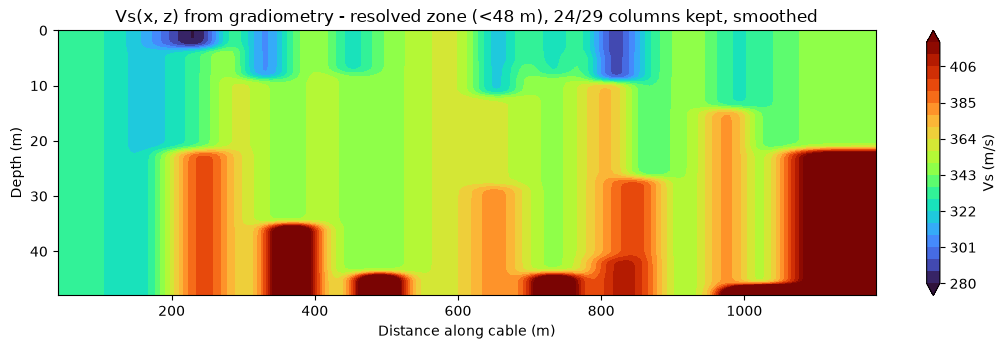

saved -> ../results/inv/vs2d_section.npz
resolved-zone lateral Vs std: 19 m/s  (small => laterally ~uniform site)


In [4]:
# ---- Display: resolved zone only, bad-fit columns dropped, densified + smoothed ----
# (This is what makes a per-column inversion look like a section instead of blocks:
#  show only the constrained depths, reject noisy columns, interpolate laterally,
#  then lightly Gaussian-smooth -- mirrors das_ani's plot_2d_contour_section.)
from scipy.ndimage import gaussian_filter

data = np.load("../results/inv/vs2d_section.npz", allow_pickle=True)  # reload for clarity
x_cols, Z_GRID, vs2d, misfits_2d = data['x'], data['z'], data['vs'], data['misfit']

ZMAX_RES = 48.0                                   # 3-8 Hz constrains only ~< 50 m
mis  = np.array(misfits_2d)
good = mis <= 2.5 * np.median(mis)                # drop poorly-fit (noisy) columns
Vd = vs2d.copy(); Vd[:, ~good] = np.nan

zmask = Z_GRID <= ZMAX_RES
Zr = Z_GRID[zmask]

def _lat_fill(row, xr, xf):
    ok = np.isfinite(row)
    if ok.sum() < 2:
        return np.full_like(xf, np.nanmedian(row) if ok.any() else np.nan)
    return np.interp(xf, xr[ok], row[ok])         # interpolate across dropped columns

xf = np.linspace(x_cols.min(), x_cols.max(), 240)
Vr = np.vstack([_lat_fill(Vd[i], x_cols, xf) for i in np.where(zmask)[0]])
Vr = gaussian_filter(Vr, sigma=(1.2, 4.0))        # gentle (depth, lateral) smoothing

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.contourf(xf, Zr, Vr, levels=np.linspace(280, 420, 21), cmap="turbo", extend="both")
ax.invert_yaxis()
ax.set_xlabel("Distance along cable (m)"); ax.set_ylabel("Depth (m)")
ax.set_title(f"Vs(x, z) from gradiometry - resolved zone (<{ZMAX_RES:.0f} m), "
             f"{int(good.sum())}/{len(good)} columns kept, smoothed")
plt.colorbar(im, label="Vs (m/s)")
plt.tight_layout(); plt.show()

lat_std = np.nanstd(np.nanmean(vs2d[zmask][:, good], axis=0))
print(f"saved -> ../results/inv/vs2d_section.npz")
print(f"resolved-zone lateral Vs std: {lat_std:.0f} m/s  (small => laterally ~uniform site)")